In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# ***Problem Statement***
***Predict the daily number of audience members visiting each movie theater using historical booking and visit records, theater metadata, and calendar features. The goal is to produce accurate day-level audience forecasts for every theater in the sample_submission.csv file.***

# ***Importing Libraries***

In [2]:
import numpy as np
import pandas as pd

from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score, make_scorer

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

print('Libraries loaded')

Libraries loaded


# ***Data Loading***

In [3]:
booknow_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
booknow_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
booknow_visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
cinePOS_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
cinePOS_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
movie_theater_id_relation = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')
sample_submission = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')

In [4]:
print(f'booknow_booking shape: {booknow_booking.shape}')
print(f'booknow_theaters shape: {booknow_theaters.shape}')
print(f'booknow_visits shape: {booknow_visits.shape}')
print(f'cinePOS_booking shape: {cinePOS_booking.shape}')
print(f'cinePOS_theaters shape: {cinePOS_theaters.shape}')
print(f'date_info shape: {date_info.shape}')
print(f'movie_theater_id_relation shape: {movie_theater_id_relation.shape}')
print(f'sample_submission shape: {sample_submission.shape}')

booknow_booking shape: (68336, 4)
booknow_theaters shape: (829, 5)
booknow_visits shape: (214046, 3)
cinePOS_booking shape: (1641966, 4)
cinePOS_theaters shape: (4690, 5)
date_info shape: (547, 2)
movie_theater_id_relation shape: (150, 2)
sample_submission shape: (38062, 2)


In [5]:
booknow_booking.head(2)
# booknow_booking['book_theater_id'].unique()

,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3


In [6]:
booknow_theaters.head(2)
# booknow_theaters['book_theater_id'].unique()

,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017


In [7]:
booknow_visits.head()
# booknow_visits['book_theater_id'].unique()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [8]:
cinePOS_booking.head(2)

,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3


In [9]:
cinePOS_theaters.head(2)

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017


In [10]:
date_info.head()

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


In [11]:
movie_theater_id_relation.head(2)

,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467


In [12]:
sample_submission.head(2)

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0


## ***Train Data***

In [13]:
train_data = booknow_visits.copy()
train_data.rename(columns={'show_date': 'date'}, inplace=True)
train_data['date'] = pd.to_datetime(train_data['date'])
print(f'Shape: {train_data.shape}')
train_data.head()

Shape: (214046, 3)


,book_theater_id,date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


## ***Test Data***

In [14]:
test_data = sample_submission.copy()
test_data['book_theater_id'] = test_data['ID'].apply(lambda x: '_'.join(x.split('_')[:2]))
test_data['date'] = test_data['ID'].apply(lambda x: x.split('_')[2])
test_data['date'] = pd.to_datetime(test_data['date'])
print(f'Shape: {test_data.shape}')
test_data.head()

Shape: (38062, 4)


,ID,audience_count,book_theater_id,date
0,book_00001_2024-03-01,0,book_00001,2024-03-01
1,book_00001_2024-03-02,0,book_00001,2024-03-02
2,book_00001_2024-03-03,0,book_00001,2024-03-03
3,book_00001_2024-03-04,0,book_00001,2024-03-04
4,book_00001_2024-03-06,0,book_00001,2024-03-06


# ***Exploratory Data Analysis(EDA)***

In [15]:
train_data.shape, test_data.shape

((214046, 3), (38062, 4))

In [16]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   date             214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.9+ MB


In [17]:
train_data.describe()

,date,audience_count
count,214046,214046.000000
mean,2023-09-13 04:07:24.285807360,41.616568
min,2023-01-01 00:00:00,2.000000
25%,2023-07-09 00:00:00,18.000000
50%,2023-09-25 00:00:00,34.000000
75%,2023-12-11 00:00:00,58.000000
max,2024-02-28 00:00:00,1350.000000
std,NaN,32.834918


## **Categorical Columns in dataset**

In [18]:
train_data.select_dtypes(include=['object', 'category', 'string']).columns

Index(['book_theater_id'], dtype='object')

## **Numerical Columns in dataset**

In [19]:
train_data.select_dtypes(include=['number']).columns

Index(['audience_count'], dtype='object')

In [20]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID               38062 non-null  object        
 1   audience_count   38062 non-null  int64         
 2   book_theater_id  38062 non-null  object        
 3   date             38062 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.2+ MB


In [21]:
train_data.isnull().sum()

book_theater_id    0
date               0
audience_count     0
dtype: int64

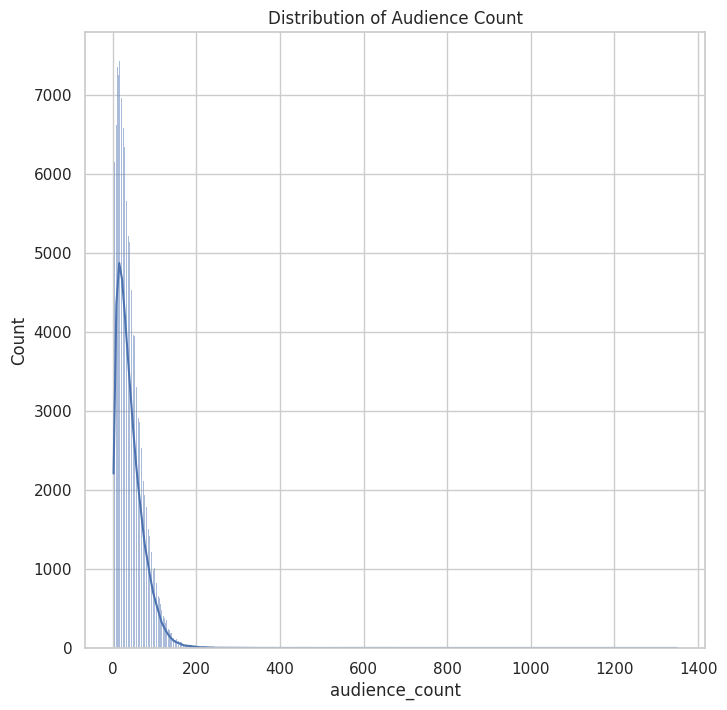

In [22]:
plt.figure(figsize=(8,8))
sns.histplot(train_data['audience_count'], kde=True)
plt.title("Distribution of Audience Count")
plt.xlabel("audience_count")
plt.show()

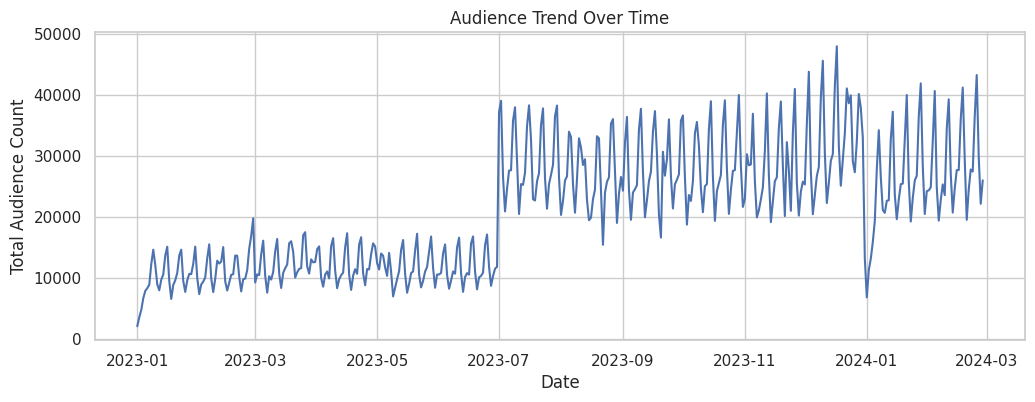

In [23]:
daily = train_data.groupby('date')['audience_count'].sum()

plt.figure(figsize=(12,4))
plt.plot(daily.index, daily.values)
plt.title("Audience Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Audience Count")
plt.show()


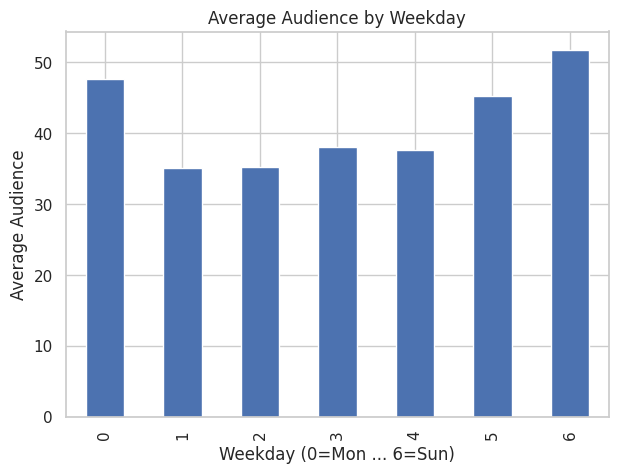

In [24]:
train_data['weekday'] = train_data['date'].dt.weekday

weekday_avg = train_data.groupby('weekday')['audience_count'].mean()

plt.figure(figsize=(7,5))
weekday_avg.plot(kind='bar')
plt.title("Average Audience by Weekday")
plt.xlabel("Weekday (0=Mon ... 6=Sun)")
plt.ylabel("Average Audience")
plt.show()


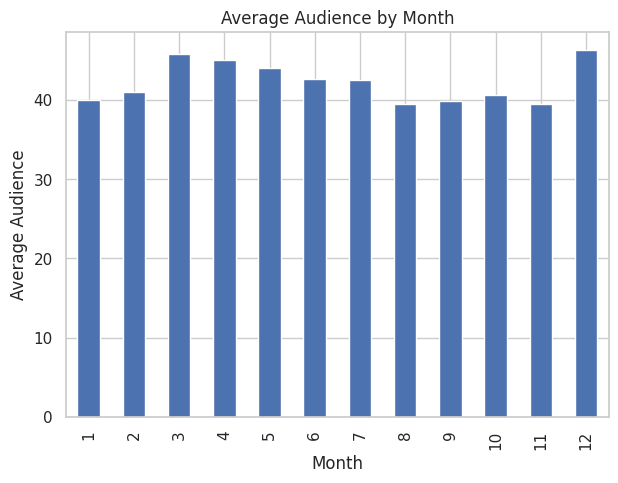

In [25]:
train_data['month'] = train_data['date'].dt.month

month_avg = train_data.groupby('month')['audience_count'].mean()

plt.figure(figsize=(7,5))
month_avg.plot(kind='bar')
plt.title("Average Audience by Month")
plt.xlabel("Month")
plt.ylabel("Average Audience")
plt.show()


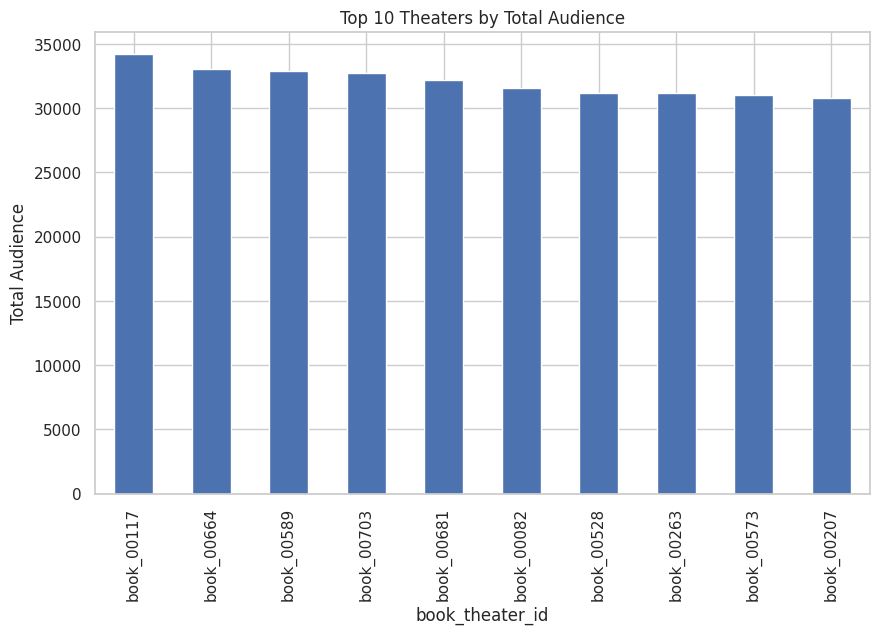

In [26]:
theater_totals = train_data.groupby('book_theater_id')['audience_count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
theater_totals.plot(kind='bar')
plt.title("Top 10 Theaters by Total Audience")
plt.ylabel("Total Audience")
plt.show()

# **Feature Engineering**

In [27]:
# Renaming show_date → date
date_info.rename(columns={'show_date': 'date'}, inplace=True)

# Converting to datetime format
date_info['date'] = pd.to_datetime(date_info['date'])

# Merge into train and test
train_data = train_data.merge(date_info, on='date', how='left')
test_data = test_data.merge(date_info, on='date', how='left')

# Check first rows
train_data.head()


,book_theater_id,date,audience_count,weekday,month,day_of_week
0,book_00001,2023-01-13,50,4,1,Friday
1,book_00001,2023-01-14,64,5,1,Saturday
2,book_00001,2023-01-15,58,6,1,Sunday
3,book_00001,2023-01-16,44,0,1,Monday
4,book_00001,2023-01-18,12,2,1,Wednesday


In [28]:
test_data.shape

(38062, 5)

In [29]:
def add_date_feats(df):
    df['day'] = df['date'].dt.day
    df['weekday'] = df['date'].dt.weekday            # Mon=0 .. Sun=6
    df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['date'].dt.quarter
    return df

train_data = add_date_feats(train_data)
test_data  = add_date_feats(test_data)

In [30]:
grp = train_data.groupby('book_theater_id')['audience_count']
theater_mean = grp.mean().rename('theater_mean')
theater_median = grp.median().rename('theater_median')
theater_std = grp.std().fillna(0).rename('theater_std')
theater_count = grp.count().rename('theater_count')

agg_df = pd.concat([theater_mean, theater_median, theater_std, theater_count], axis=1).reset_index()
agg_df.head()

# merge into train and test
train_data = train_data.merge(agg_df, on='book_theater_id', how='left')
test_data  = test_data.merge(agg_df, on='book_theater_id', how='left')

# fill missing (theaters in test not in train)
for c in ['theater_mean','theater_median','theater_std','theater_count']:
    test_data[c].fillna(train_data['audience_count'].mean(), inplace=True)
    train_data[c].fillna(train_data['audience_count'].mean(), inplace=True)


In [31]:
# train_data = train_data.sort_values(['book_theater_id','date']).reset_index(drop=True)

# # adding lag and roll
# def add_lags_rolls(df, lags=[1,7], windows=[3,7]):
#     df = df.copy()
#     df[['lag_'+str(l) for l in lags]] = np.nan  # placeholder
#     for l in lags:
#         df['lag_'+str(l)] = df.groupby('book_theater_id')['audience_count'].shift(l)
  
#     for w in windows:
#         df[f'roll_mean_{w}'] = df.groupby('book_theater_id')['audience_count'].shift(1).rolling(window=w, min_periods=1).mean().reset_index(level=0, drop=True)
#     return df

# train_data = add_lags_rolls(train_data, lags=[1,7], windows=[3,7])

# train_data[['lag_1','lag_7','roll_mean_3','roll_mean_7']].head(10)

In [32]:
train_data.isnull().sum()

book_theater_id    0
date               0
audience_count     0
weekday            0
month              0
day_of_week        0
day                0
is_weekend         0
day_of_year        0
week_of_year       0
quarter            0
theater_mean       0
theater_median     0
theater_std        0
theater_count      0
dtype: int64

In [33]:
# train_data = train_data.dropna(subset=['lag_1','lag_7','roll_mean_3','roll_mean_7'])
# train_data.isnull().sum()

# Label Encoding

In [34]:
le = LabelEncoder()
all_ids = pd.concat([train_data['book_theater_id'], test_data['book_theater_id']]).astype(str)
le.fit(all_ids)
train_data['book_id_le'] = le.transform(train_data['book_theater_id'].astype(str))
test_data['book_id_le']  = le.transform(test_data['book_theater_id'].astype(str))


In [35]:
# dropping day of week column
train_data.drop('day_of_week', axis = 1, inplace = True)
test_data.drop('day_of_week', axis = 1, inplace = True)

In [36]:
train_data.head(2)

,book_theater_id,date,audience_count,weekday,month,day,is_weekend,day_of_year,week_of_year,quarter,theater_mean,theater_median,theater_std,theater_count,book_id_le
0,book_00001,2023-01-13,50,4,1,13,0,13,2,1,47.05848,46.0,23.388397,342,0
1,book_00001,2023-01-14,64,5,1,14,1,14,2,1,47.05848,46.0,23.388397,342,0


In [37]:
test_data.head(2)

,ID,audience_count,book_theater_id,date,day,weekday,is_weekend,month,day_of_year,week_of_year,quarter,theater_mean,theater_median,theater_std,theater_count,book_id_le
0,book_00001_2024-03-01,0,book_00001,2024-03-01,1,4,0,3,61,9,1,47.05848,46.0,23.388397,342.0,0
1,book_00001_2024-03-02,0,book_00001,2024-03-02,2,5,1,3,62,9,1,47.05848,46.0,23.388397,342.0,0


# **Train / Valid Split**

In [38]:
train_data['date'].min(), train_data['date'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2024-02-28 00:00:00'))

In [39]:
train = train_data[train_data['date'] < "2024-01-01"]
valid = train_data[train_data['date'] >= "2024-01-01"]

In [40]:
X_train = train.drop(['audience_count','book_theater_id','date'], axis=1)
y_train = train['audience_count']

X_valid = valid.drop(['audience_count','book_theater_id','date'], axis=1)
y_valid = valid['audience_count']

## **X_train & y_train shape**

In [41]:
X_train.shape, y_train.shape

((174535, 12), (174535,))

In [42]:
X_train.head(2)

,weekday,month,day,is_weekend,day_of_year,week_of_year,quarter,theater_mean,theater_median,theater_std,theater_count,book_id_le
0,4,1,13,0,13,2,1,47.05848,46.0,23.388397,342,0
1,5,1,14,1,14,2,1,47.05848,46.0,23.388397,342,0


In [43]:
y_train.head(2)

0    50
1    64
Name: audience_count, dtype: int64

## **X_valid & y_valid shape**

In [44]:
X_valid.shape, y_valid.shape

((39511, 12), (39511,))

In [45]:
X_valid.head(2)

,weekday,month,day,is_weekend,day_of_year,week_of_year,quarter,theater_mean,theater_median,theater_std,theater_count,book_id_le
292,4,1,5,0,5,1,1,47.05848,46.0,23.388397,342,0
293,5,1,6,1,6,1,1,47.05848,46.0,23.388397,342,0


In [46]:
y_valid.head(2)

292    22
293    42
Name: audience_count, dtype: int64

# **Preparing test data for model**

In [47]:
# full = pd.concat([train_data, test_data], axis=0)
# full = full.sort_values(["book_theater_id", "date"])
# full["lag_1"] = full.groupby("book_theater_id")["audience_count"].shift(1)
# full["lag_7"] = full.groupby("book_theater_id")["audience_count"].shift(7)

# full["roll_mean_3"] = full.groupby("book_theater_id")["audience_count"].transform(lambda x: x.rolling(3).mean())
# full["roll_mean_7"] = full.groupby("book_theater_id")["audience_count"].transform(lambda x: x.rolling(7).mean())

In [48]:
# Separating train data and test data

# train_processed = full[full["audience_count"] != 0]
# test_processed  = full[full["audience_count"] == 0]
# train_processed.head(2)


In [49]:
X_test = test_data.drop(["ID", "audience_count","date", "book_theater_id"], axis = 1)
print(X_test.shape)

(38062, 12)


# ***Model Building***

## **Random Forest**

In [50]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_valid)
# rf_mae = mean_absolute_error(y_valid, rf_preds)
# print("Random Forest MAE:", rf_mae)
r2_score(y_valid, rf_preds)

0.22169582342889127

## **XGBoost**

In [51]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_valid)
r2_score(y_valid, xgb_preds)

0.4067790825808667

## **CatBoost**

In [52]:
from catboost import CatBoostRegressor, Pool

model = CatBoostRegressor(
    loss_function='MAE',
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    verbose=200,
    task_type="CPU"
)

model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

preds = model.predict(X_valid)
mae = mean_absolute_error(y_valid, preds)
r2 = r2_score(y_valid, preds)

print("MAE:", mae)
print("R2 Score:", r2)

0:	learn: 23.7116865	test: 22.6654501	best: 22.6654501 (0)	total: 84.4ms	remaining: 1m 24s
200:	learn: 15.6842364	test: 15.6086277	best: 15.5812004 (154)	total: 4.87s	remaining: 19.4s
400:	learn: 15.3203143	test: 15.8817192	best: 15.5812004 (154)	total: 9.6s	remaining: 14.3s
600:	learn: 15.0142894	test: 15.9357041	best: 15.5812004 (154)	total: 14.3s	remaining: 9.47s
800:	learn: 14.7667750	test: 16.0190012	best: 15.5812004 (154)	total: 19.1s	remaining: 4.74s
999:	learn: 14.5603516	test: 16.1003977	best: 15.5812004 (154)	total: 23.9s	remaining: 0us

bestTest = 15.58120038
bestIteration = 154

Shrink model to first 155 iterations.
MAE: 15.581201378032704
R2 Score: 0.46089474849833056


# **HyperParameter Tuning**

In [53]:
#XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)

xgb_param = {
    'max_depth': [2, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.08, 0.1],
    'n_estimators': [200, 400, 800]
}

#Catboost

cat_model = CatBoostRegressor(loss_function="MAE",task_type='CPU',random_state=42,verbose=False)

cat_param = {
    'depth': [4, 6, 8],
    'learning_rate': [0.02, 0.03, 0.05],
    'l2_leaf_reg': [3, 5, 7],
    'iterations': [500, 800, 1000]
}


tscv = TimeSeriesSplit(n_splits=3)
scorer = 'neg_mean_absolute_error'

In [54]:
# XGBoost tuning
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param,
    n_iter=20,
    scoring=scorer,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)
xgb_search.fit(X_train, y_train)

print("Best XGB params:", xgb_search.best_params_)
print("Best XGB (neg MAE):", xgb_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}
Best XGB (neg MAE): -16.220560694020474


In [55]:
#CatBoost tuning

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_param,
    n_iter=10,
    scoring=scorer,
    cv=3,
    random_state=42,
    verbose=2
)

cat_search.fit(X_train, y_train)

print("Best params:", cat_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.02; total time=   7.1s
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.02; total time=   7.0s
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.02; total time=   7.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.02; total time=   5.9s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.02; total time=   6.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.02; total time=   5.9s
[CV] END depth=4, iterations=1000, l2_leaf_reg=5, learning_rate=0.03; total time=  12.0s
[CV] END depth=4, iterations=1000, l2_leaf_reg=5, learning_rate=0.03; total time=  11.8s
[CV] END depth=4, iterations=1000, l2_leaf_reg=5, learning_rate=0.03; total time=  11.9s
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.03; total time=   7.0s
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learnin

In [56]:
best_cat = CatBoostRegressor(
    loss_function='MAE',
    random_state=42,
    verbose=100,
    learning_rate= 0.03,
    l2_leaf_reg= 7,
    iterations=800,
    depth = 8   
)

best_cat.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

cat_val_pred = best_cat.predict(X_valid)

print("CAT MAE on valid:", mean_absolute_error(y_valid, cat_val_pred))
print("CAT R2 on valid:", r2_score(y_valid, cat_val_pred))

0:	learn: 23.7165258	test: 22.6755304	best: 22.6755304 (0)	total: 29.8ms	remaining: 23.8s
100:	learn: 16.0207433	test: 15.6128871	best: 15.6074974 (93)	total: 2.45s	remaining: 16.9s
200:	learn: 15.6926090	test: 15.6261677	best: 15.5525446 (123)	total: 4.82s	remaining: 14.4s
300:	learn: 15.5078776	test: 15.6824482	best: 15.5525446 (123)	total: 7.13s	remaining: 11.8s
400:	learn: 15.3318408	test: 15.7643434	best: 15.5525446 (123)	total: 9.41s	remaining: 9.36s
500:	learn: 15.1702838	test: 15.8616802	best: 15.5525446 (123)	total: 11.8s	remaining: 7.01s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=400; total time=   2.6s
[CV] END ..learning_rate=0.08, max_depth=2, n_estimators=800; total time=   3.5s
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=400; total time=   4.1s
[CV] END ..learning_rate=0.05, max_depth=2, n_estimators=200; total time=   1.0s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=400; total time=   4.1s
[CV] END ..learning_rate=0.08, max_depth=

In [57]:

best_xgb = xgb_search.best_estimator_

xgb_val_pred = best_xgb.predict(X_valid)

print("XGB MAE on valid:", mean_absolute_error(y_valid, xgb_val_pred))
print("XGB R2 on valid:", r2_score(y_valid, xgb_val_pred))

XGB MAE on valid: 16.17414816292811
XGB R2 on valid: 0.45386208413197415


In [58]:
X_test.shape

(38062, 12)

In [59]:
predictions = best_cat.predict(X_test)
predictions

array([43.23986865, 53.17767741, 58.78906202, ..., 13.47769293,
       14.57404805, 11.17478972])

# **Final Submission**

In [60]:
sub = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')
sub['audience_count'] = predictions
submission_final = sub[['ID','audience_count']]
submission_final.to_csv('submission.csv', index=False)